In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from src.model import SpamClassifier
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from datasets import load_dataset

e:\Projects\AI Text Classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset('sms_spam')
df = pd.DataFrame(dataset['train'])
texts = df['sms'].tolist()
labels = df['label'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2,
    random_state=42, stratify=labels
)
print(f'Validation size: {len(X_val)}')

Validation size: 1115


In [3]:
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [4]:
device = torch.device('cpu')
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = SpamClassifier()
model.load_state_dict(torch.load('../saved_model/model.pt', map_location=device))
model.eval()

val_dataset = SpamDataset(X_val, y_val, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=64)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        logits = model(batch['input_ids'].to(device),
                       batch['attention_mask'].to(device))
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

print('Inference done')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3792.42it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Inference done


In [5]:
print(classification_report(y_val, all_preds,
      target_names=['ham', 'spam']))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.97      0.97      0.97       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



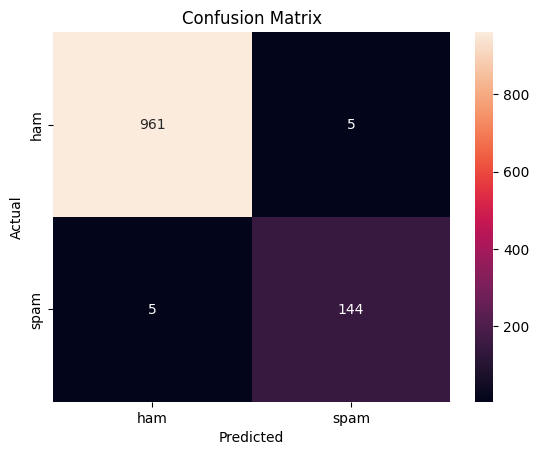

In [6]:
cm = confusion_matrix(y_val, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
val_df = pd.DataFrame({
    'text': X_val,
    'true': y_val,
    'pred': all_preds
})
failures = val_df[val_df['true'] != val_df['pred']]
print(f'Total failures: {len(failures)}')

print('\nFalse positives (ham predicted as spam):')
print(failures[failures['true']==0]['text'].head(3).values)

print('\nFalse negatives (spam missed):')
print(failures[failures['true']==1]['text'].head(3).values)

Total failures: 10

False positives (ham predicted as spam):
<ArrowStringArray>
[                                                                                                       'MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*\n',
                                                                           'Somebody set up a website where you can play hold em using eve online spacebucks\n',
 'Im in inperialmusic listening2the weirdest track ever byleafcutter john-sounds like insects being molested&someone plumbing,remixed by evil men on acid!\n']
Length: 3, dtype: str

False negatives (spam missed):
<ArrowStringArray>
[                                                                       'Bought one ringtone and now getting texts costing 3 pound offering more tones etc\n',
 'ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringing in a real breath of sunshine.\n',
                                              